In [1]:
import random

In [2]:
import matplotlib.pyplot as plt

In [ ]:
import csv


def find_max_map(file_path):
    with open(file_path, mode="r", newline="") as csvfile:
        reader = csv.reader(x.replace("\0", "") for x in csvfile)
        header = next(reader)  # Read the header
        # Find the index of the 'metrics/mAP50-95(B)' column (8th column, zero-indexed as 7)
        map_column_index = 7

        # Initialize max value
        max_map_value = float("-inf")

        # Iterate over the rows and find the max value
        for row in reader:
            try:
                # Convert the value to float and update max_map_value if current value is higher
                map_value = float(row[map_column_index].strip())
                max_map_value = max(max_map_value, map_value)
            except ValueError:
                # Handle cases where conversion to float fails (e.g., empty or non-numeric values)
                continue

        return max_map_value


# Example usage:
# max_value = find_max_map('your_file.csv')
# print("Max mAP50-95(B):", max_value)

In [4]:
def find_max_metric(file_path, metric_column):
    """
    Extracts the maximum value for a specified metric from a CSV file.

    :param file_path: Path to the CSV file.
    :param metric_column: Name of the column containing the desired metric.
    :return: The maximum value for the specified metric, or None if not found.
    """
    with open(file_path, mode="r", newline="") as csvfile:
        reader = csv.reader(x.replace("\0", "") for x in csvfile)
        headers = next(reader)  # Read the headers row
        headers = [x.lstrip() for x in headers]
        # Get the index of the specified metric column
        if metric_column == "fscore":
            precision_index = headers.index("metrics/precision(B)")
            recall_index = headers.index("metrics/recall(B)")
            max_metric_value = float("-inf")
            found = False

            # Iterate over the rows to find the max value for the specified column
            for row in reader:
                try:
                    precision = float(row[precision_index].strip())
                    recall = float(row[recall_index].strip())
                    fscore = 2 * precision * recall / (precision + recall)
                    max_metric_value = max(max_metric_value, fscore)
                    found = True
                except (ValueError, IndexError):
                    # Skip rows with invalid or missing values
                    continue
        else:
            try:
                column_index = headers.index(metric_column)
            except ValueError:
                raise ValueError(f"Column '{metric_column}' not found in CSV headers.")

            max_metric_value = float("-inf")
            found = False

            # Iterate over the rows to find the max value for the specified column
            for row in reader:
                try:
                    metric_value = float(row[column_index].strip())
                    max_metric_value = max(max_metric_value, metric_value)
                    found = True
                except (ValueError, IndexError):
                    # Skip rows with invalid or missing values
                    continue

        return max_metric_value if found else None

In [5]:
def get_results(methods, base_path, fractions, metric):
    # Initialize results
    results = {key: [] for key in methods.keys()}

    # Populate results
    for fraction in fractions:
        for method, info in methods.items():
            if fraction == "0.2" and "random" not in method:
                # Only "random" exists for 0.2; append None or a default value
                results[method].append(None)  # Or use a fallback value if needed
            else:
                file_path = base_path.format(
                    method=info["path"].format(fraction=fraction)
                )
                results[method].append(find_max_metric(file_path, metric))

    # Special handling for missing values (e.g., for 0.2 in non-random methods)
    for method in methods.keys():
        if results[method][0] is None:
            results[method][0] = results["random"][
                0
            ]  # Assign the random value if necessary

    return results

In [6]:
linestyles = ["-", "--", "-.", ":", "-", "-", "--", ":", ":"]
markers = ["o", "v", "^", "<", "o", "o", "s", "<", "v"]

In [7]:
import matplotlib

In [8]:
font = {"size": 14}

matplotlib.rc("font", **font)

In [9]:
import pandas as pd


def get_metrics_dataframe(methods, base_path, fractions, metrics):
    data = []
    index = []

    for metric in metrics:
        results = get_results(methods, base_path, fractions, metric)

        for method in methods:
            data.append([round(x, 4) for x in results[method]])
            index.append((metric, method))

    df = pd.DataFrame(
        data,
        index=pd.MultiIndex.from_tuples(index, names=["Metric", "Method"]),
        columns=fractions,
    )

    return df

In [10]:
def plot_metrics(methods, base_path, fractions, metric, title=None):

    # Initialize results
    results = get_results(methods, base_path, fractions, metric)
    # Plot results
    print(results)
    for i, item in enumerate(methods.items()):
        method, info = item
        plt.plot(
            fractions,
            results[method],
            ls=linestyles[i],
            marker=markers[i],
            c=info["color"],
            label=info["label"],
            alpha=0.8,
        )

    plt.legend()
    if title is not None:
        plt.title(title)
    plt.xlabel("Относительный размер обучающей выборки")
    plt.ylabel(metric.replace("(B)", "").replace("metrics/", ""))

In [ ]:
base_path = "/home/setupishe/ultralytics/runs/detect/VOC_{method}/results.csv"
fractions = ["0.2"] + [f"0.{i}" for i in range(3, 8)]

# Define base paths and labels
methods = {
    "random_matryoshka_m": {
        "path": "random_{fraction}_m_matryoshka_everything",
        "label": "random_matryoshka_m",
        "color": [1, 0, 0],
    },
    "distance_matryoshka_m_pseudo": {
        "path": "distance_{fraction}_m_matryoshka_everything_really_everything_pseudo",
        "label": "distance_matryoshka_pseudo",
        "color": [0.3, 0.4, 0.8],
    },
    "distance_matryoshka_m": {
        "path": "distance_{fraction}_m_matryoshka_everything_really_everything",
        "label": "distance_matryoshka",
        "color": [0.3, 0.4, 0.8],
    },
    "random": {
        "path": "random_{fraction}_s_matryoshka",
        "label": "random",
        "color": [1, 0.6, 0.3],
    },
    "distance_pseudo": {
        "path": "distance_{fraction}_m_pseudo",
        "label": "distance_pseudo",
        "color": [1, 0, 1],
    },
    # "random_weights_decreasing": {
    #     "path": "random_{fraction}_s_matryoshka_weights_decreasing",
    #     "label": "random_weights_decreasing",
    #     "color": [1, 1, 0],
    # },
    # "random_regular": {
    #     "path": "random_{fraction}_s",
    #     "label": "random_regular",
    #     "color": [1, 0, 1],
    # },
    # "distance_iter_correct": {
    #     "path": "distance_{fraction}_s_matryoshka_iter_correct",
    #     "label": "distance_matryoska",
    #     "color": [0, 1, 0],
    # },
    # "distance_iter_correct_ctf": {
    #     "path": "distance_{fraction}_s_matryoshka_iter_correct_ctf",
    #     "label": "distance_matryoska_correct_ctf",
    #     "color": [1, 0, 1],
    # },
    # "distance_regular": {
    #     "path": "distance_{fraction}_s",
    #     "label": "distance_regular",
    #     "color": [0.5, 0.2, 1],
    # },
    # "distance": {
    #     "path": "distance_{fraction}_m_matryoshka",
    #     "label": "distance",
    #     "color": [0, 0, 1],
    # },
    # "confidences": {
    #     "path": "confidences_{fraction}_s_matryoshka",
    #     "label": "confidences",
    #     "color": [0, 1, 1],
    # },
    # "random": {
    #     "path": "random_{fraction}_s_matryoshka_everything",
    #     "label": "random_everything",
    #     "color": [0.2, 0.5, 0.7],
    # },
    # "distance_matryoshka_everything_really_everything": {
    #     "path": "distance_{fraction}_s_matryoshka_everything_really_everything",
    #     "label": "distance_matryoshka_everything_separate_correct",
    #     "color": [0.8, 0.3, 0.2],
    # },
    # "distance_matryoshka_everything_really_everything_pseudo": {
    #     "path": "distance_{fraction}_s_matryoshka_everything_really_everything_pseudo",
    #     "label": "distance_matryoshka_pseudo",
    #     "color": [0.3, 0.4, 0.8],
    # },
}

{'random_matryoshka_m': [0.60088, 0.62332, 0.64389, 0.66322, 0.68923, 0.68498], 'distance_matryoshka_m_pseudo': [0.56373, 0.63565, 0.6547, 0.66395, 0.67637, 0.69008], 'distance_matryoshka_m': [0.56373, 0.63335, 0.66383, 0.66778, 0.69436, 0.69301], 'random': [0.56373, 0.58527, 0.60681, 0.62107, 0.62946, 0.6383], 'distance_pseudo': [0.56373, 0.63345, 0.65167, 0.67, 0.68758, 0.6908]}
{'random_matryoshka_m': [0.7573007857914571, 0.7738786719589313, 0.7869271544426536, 0.8060315792018448, 0.8164393645622179, 0.8186430760967749], 'distance_matryoshka_m_pseudo': [0.7430765869853917, 0.7855215165744276, 0.7985423911710606, 0.8090317916790197, 0.8145142663493504, 0.8247309587779414], 'distance_matryoshka_m': [0.7430765869853917, 0.7783678715024311, 0.803615399362214, 0.8096426620423226, 0.8177868352526957, 0.8227902620567354], 'random': [0.7430765869853917, 0.7655481351670045, 0.773502713858219, 0.7851847268263519, 0.791531872311438, 0.7982554578420216], 'distance_pseudo': [0.7430765869853917, 

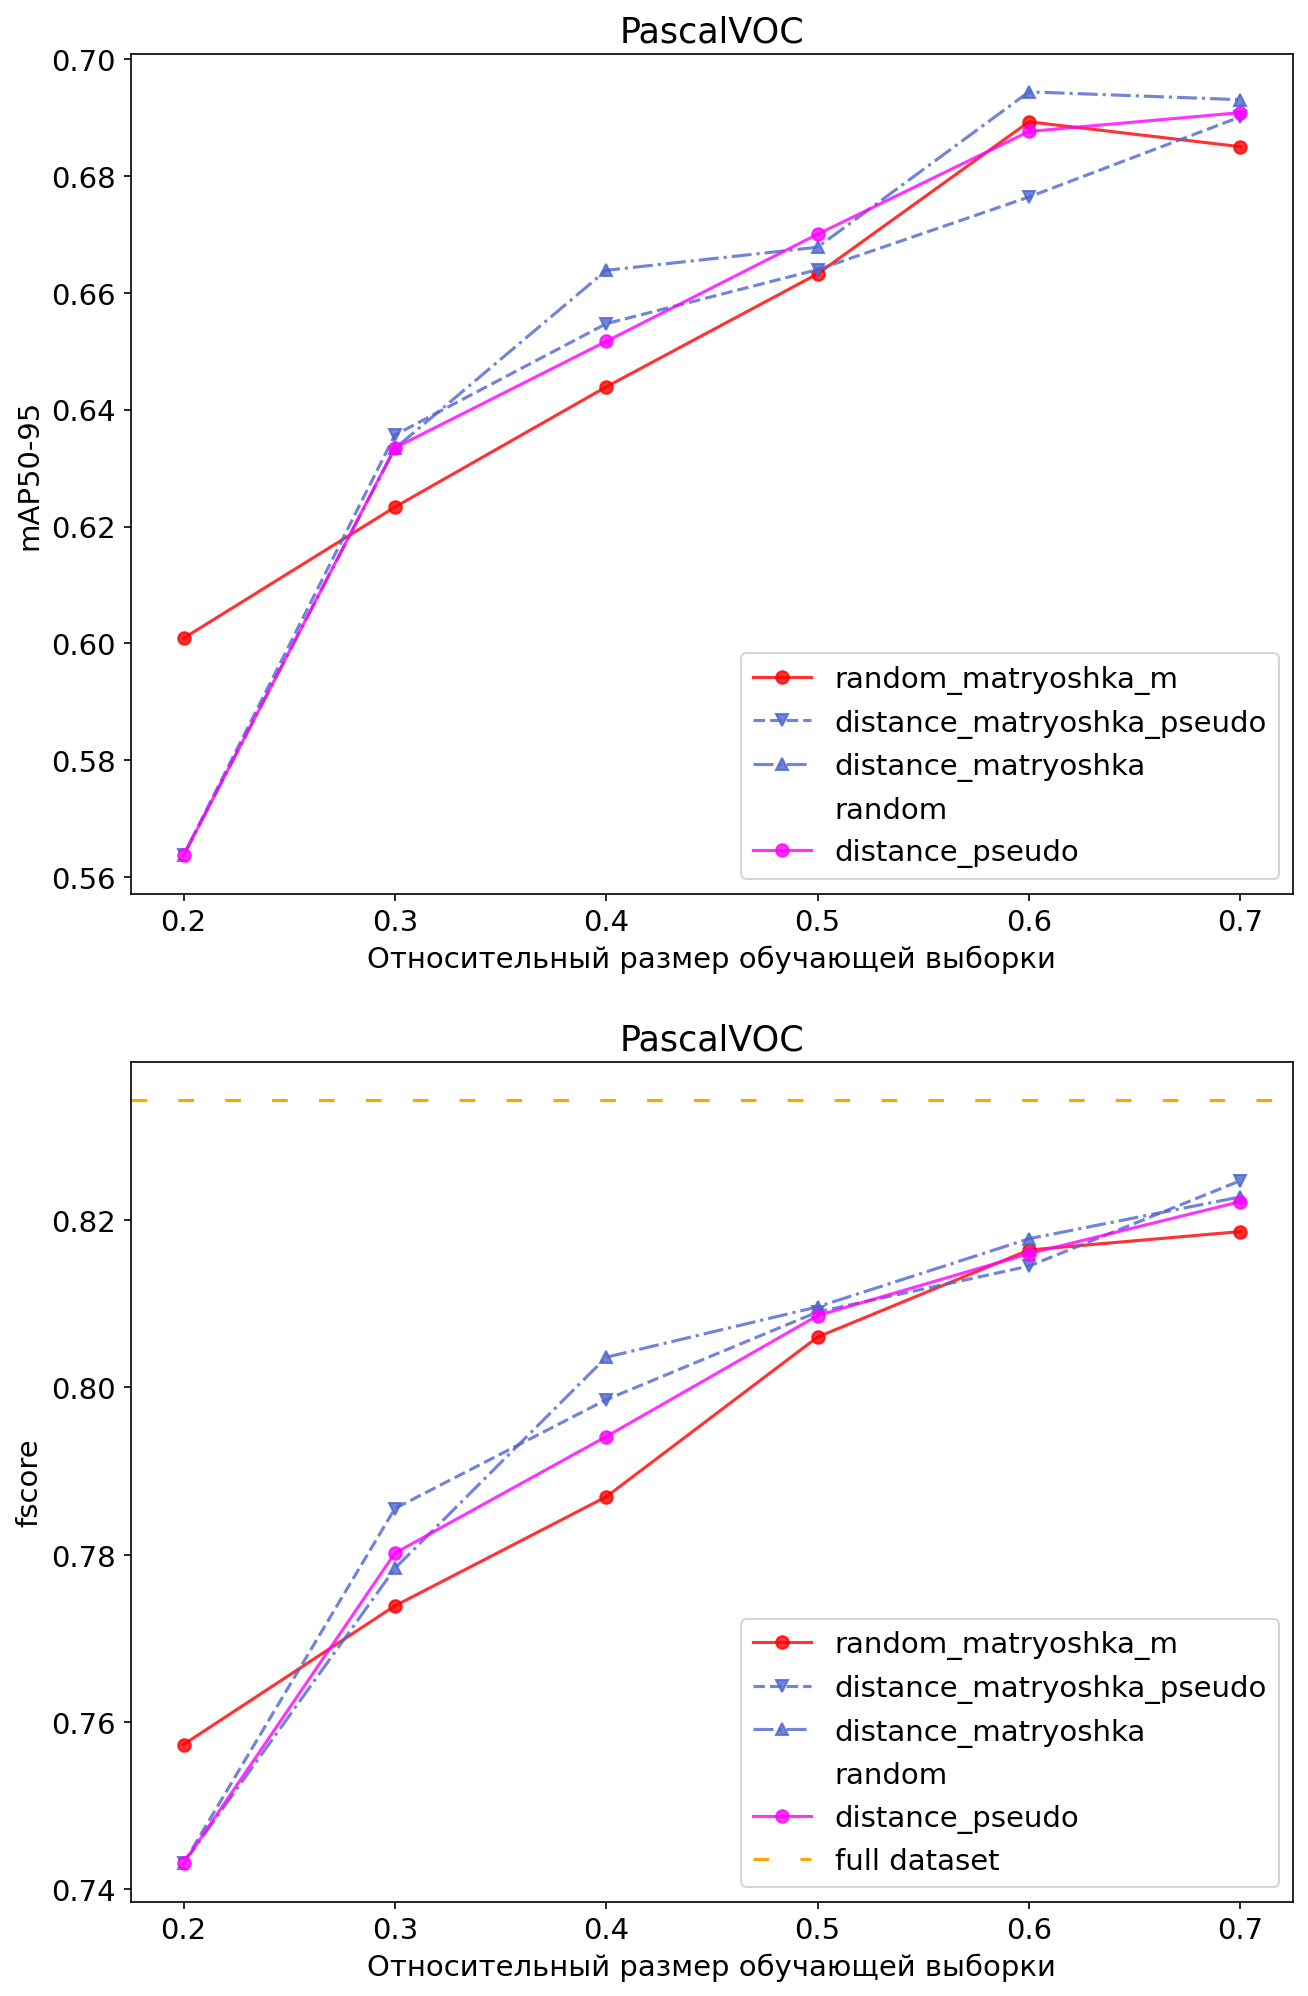

In [16]:
# Create a figure with two subplots side by side
plt.figure(figsize=(10, 16), dpi=150)  # Adjust the size as needed

# First subplot
plt.subplot(2, 1, 1)  # 1 row, 2 columns, first plot
plot_metrics(methods, base_path, fractions, "metrics/mAP50-95(B)", "PascalVOC")
# plt.axhline(y=0.71016, color="orange", linestyle=(0, (5, 10)), label="full dataset")
plt.legend()

# Second subplot
plt.subplot(2, 1, 2)  # 1 row, 2 columns, second plot
plot_metrics(methods, base_path, fractions, "fscore", "PascalVOC")
plt.axhline(y=0.8344, color="orange", linestyle=(0, (5, 10)), label="full dataset")
plt.legend()
plt.savefig("matryoshka_results.png")

In [21]:
df = get_metrics_dataframe(
    methods, base_path, fractions, ["metrics/mAP50-95(B)", "fscore"]
)
df["mean"] = df[["0.3", "0.4", "0.5", "0.6", "0.7"]].mean(axis=1)

In [22]:
df

0.2     0.3     0.4     0.5  \
Metric              Method                                                  
metrics/mAP50-95(B) random_matryoshka_m    0.6009  0.6233  0.6439  0.6632   
                    distance_matryoshka_m  0.5637  0.6357  0.6547  0.6640   
                    random                 0.5637  0.5853  0.6068  0.6211   
fscore              random_matryoshka_m    0.7573  0.7739  0.7869  0.8060   
                    distance_matryoshka_m  0.7431  0.7855  0.7985  0.8090   
                    random                 0.7431  0.7655  0.7735  0.7852   

                                              0.6     0.7     mean  
Metric              Method                                          
metrics/mAP50-95(B) random_matryoshka_m    0.6892  0.6850  0.66092  
                    distance_matryoshka_m  0.6764  0.6901  0.66418  
                    random                 0.6295  0.6383  0.61620  
fscore              random_matryoshka_m    0.8164  0.8186  0.80036  
                    distance_matryoshka_m  0.8145  0.8247  0.80644  
                    random                 0.7915  0.7983  0.78280

In [17]:
import pandas as pd

fractions = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
methods = ["Random", "Distance", "Density", "Confidence"]

# COCO mAP50-95 values
coco_map = {
    "Random": [0.45101, 0.45295, 0.46053, 0.47038, 0.47741, 0.48149],
    "Distance": [0.45101, 0.45632, 0.47164, 0.47766, 0.48179, 0.48608],
    "Density": [0.45101, 0.44941, 0.45865, 0.46907, 0.47289, 0.47917],
    "Confidence": [0.45101, 0.44914, 0.46389, 0.47515, 0.47979, 0.48617],
}

# COCO F-score values
coco_fscore = {
    "Random": [0.6212, 0.6172, 0.6287, 0.6307, 0.6391, 0.6436],
    "Distance": [0.6212, 0.6244, 0.6381, 0.6424, 0.6474, 0.6489],
    "Density": [0.6212, 0.6166, 0.6238, 0.6327, 0.6341, 0.6421],
    "Confidence": [0.6212, 0.6162, 0.6272, 0.6369, 0.6402, 0.6436],
}

# VOC mAP50-95 values
voc_map = {
    "Random": [0.59289, 0.62191, 0.63963, 0.66019, 0.67845, 0.68334],
    "Distance": [0.59289, 0.63859, 0.65111, 0.66572, 0.68463, 0.69035],
    "Density": [0.59289, 0.61370, 0.64206, 0.65957, 0.68556, 0.68870],
    "Confidence": [0.59289, 0.62376, 0.64808, 0.65917, 0.67107, 0.68396],
}

# VOC F-score values
voc_fscore = {
    "Random": [0.7518, 0.7754, 0.7883, 0.8022, 0.8096, 0.8188],
    "Distance": [0.7518, 0.7875, 0.7962, 0.8091, 0.8115, 0.8196],
    "Density": [0.7518, 0.7704, 0.7871, 0.8038, 0.8134, 0.8243],
    "Confidence": [0.7518, 0.7827, 0.7941, 0.8017, 0.8123, 0.8189],
}

# Create DataFrames
df_coco_map = pd.DataFrame(coco_map, index=fractions).round(4).T
df_coco_fscore = pd.DataFrame(coco_fscore, index=fractions).round(4).T
df_voc_map = pd.DataFrame(voc_map, index=fractions).round(4).T
df_voc_fscore = pd.DataFrame(voc_fscore, index=fractions).round(4).T

In [33]:
df_voc_fscore

,0.2,0.3,0.4,0.5,0.6,0.7
Random,0.7518,0.7754,0.7883,0.8022,0.8096,0.8188
Distance,0.7518,0.7875,0.7962,0.8091,0.8115,0.8196
Density,0.7518,0.7704,0.7871,0.8038,0.8134,0.8243
Confidence,0.7518,0.7827,0.7941,0.8017,0.8123,0.8189


In [28]:
df_coco

,Fraction,Method,mAP50-95,F-score
6,0.2,Density,0.4494,0.6166
18,0.2,Density,0.4729,0.6341
0,0.2,random,0.4510,0.6212
12,0.2,random,0.4704,0.6307
7,0.3,Confidence,0.4491,0.6162
19,0.3,Confidence,0.4798,0.6402
1,0.3,Distance,0.4510,0.6212
13,0.3,Distance,0.4777,0.6424
2,0.4,Density,0.4510,0.6212
14,0.4,Density,0.4691,0.6327
